# Minimalizacja czasu realizacji (makespan) w gnieździe roboczym za pomocą PROC OPTMODEL

## Podsumowanie dla kierownictwa

Niewielka gniazdowa komórka produkcji dyskretnej musi przepchnąć cztery części — **Wspornik**, **Kołnierz**, **Obudowę** i **Wał** — przez ustaloną sekwencję trzech operacji obróbki każda, dzieląc cztery maszyny o jednostkowej przepustowości (**Piła**, **Frezarka**, **Wiertarka**, **Szlifierka**). Żadna maszyna nie może wykonywać dwóch operacji naraz, a operacje każdej części muszą przebiegać zgodnie z ich kolejnością technologiczną. Harmonogram minimalizujący czas realizacji formułujemy jako program mieszany całkowitoliczbowy w **PROC OPTMODEL** — ze zmiennymi czasu rozpoczęcia, ograniczeniami następstwa typu zakończenie-do-rozpoczęcia oraz rozłącznymi ograniczeniami braku nakładania się (typu big-*M*) między każdą parą operacji dzielących maszynę — i rozwiązujemy go do udowodnionej optymalności.

Solver MILP zwraca **optymalny czas realizacji równy 120 minut** (`Solution Status = Optimal`, `Objective Value = 120`). Wynikowy harmonogram układa wszystkie dwanaście operacji tak, że każda maszyna obrabia najwyżej jedną część naraz, a każda część jest obrabiana w swojej wymaganej kolejności technologicznej. Dwie operacje kończą się dokładnie w minucie 120 — szlifowanie Wspornika i frezowanie Obudowy — więc obie maszyny Szlifierka i Frezarka leżą na ścieżce krytycznej, która wyznacza długość harmonogramu.

## Źródła danych

Wszystkie dane są zdefiniowane w samym notatniku — brak plików zewnętrznych i sieci.

| Zbiór danych | Wiersze | Zmienne kluczowe | Opis |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Jeden wiersz na operację (4 części × 3 operacje). `machine` (1–4) to maszyna, której operacja wymaga; `dur` to jej czas przetwarzania w minutach; `jobname`/`mname` to czytelne etykiety części i maszyny. |
| `sched` | 12 | `op`, `start`, `finish` | Wynik OPTMODEL: optymalna minuta rozpoczęcia i zakończenia każdej operacji. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` połączony z rozwiązanymi czasami, posortowany według maszyny, a następnie rozpoczęcia — harmonogram czytelny dla człowieka. |
| `mk` | 1 | `makespan` | Zrealizowany czas realizacji (najpóźniejszy czas zakończenia). |

## Problem harmonogramowania

W **gnieździe roboczym** (job shop) kilka części ("zadań") przechodzi każda przez ustaloną sekwencję operacji, a każda operacja wykonuje się na określonej maszynie. Dwie operacje nie mogą zajmować tej samej maszyny w tym samym czasie (maszyny są zasobami *jednostkowymi*), a w obrębie części operacje muszą respektować swoją kolejność technologiczną. Planista chce dobrać czasy rozpoczęcia dla każdej operacji, które honorują obie reguły, utrzymując przy tym całkowitą długość harmonogramu — **czas realizacji** (makespan) — możliwie najmniejszą.

To klasyczny problem harmonogramowania rozłącznego. Modelujemy go jako program mieszany całkowitoliczbowy:

- ciągły, lecz całkowitoliczbowy **czas rozpoczęcia** `s[o]` dla każdej operacji oraz zmienną czasu realizacji `Cmax`;
- **następstwo**: operacja *k+1* części rozpoczyna się nie wcześniej niż operacja *k* się kończy;
- **rozłączna przepustowość maszyny**: dla każdej pary operacji dzielących maszynę zmienna binarna `y` decyduje, która idzie pierwsza, a wyraz big-*M* wyłącza nieaktywne uporządkowanie — tak że obie operacje nigdy nie mogą się nakładać;
- **cel**: minimalizacja `Cmax`, który jest zmuszony być co najmniej równy czasowi zakończenia każdej operacji.

PROC OPTMODEL to procedura modelowania algebraicznego z SAS/OR; jej solver MILP znajduje *dowodliwie optymalny* najkrótszy harmonogram.

> **Uwaga o PROC CLP.** SAS oferuje również PROC CLP, silnik > programowania w logice z ograniczeniami z dedykowaną składnią > harmonogramowania (działania, zasoby, następstwo). Formuła MILP > w OPTMODEL rozwiązuje tu identyczny problem i zwraca certyfikat > optymalności, którego przeszukiwanie dopuszczalności w CLP nie daje.

## Krok 1 — Zdefiniuj instancję gniazda roboczego

Cztery części, po trzy operacje każda, na czterech maszynach. Każdy wiersz ustala maszynę, której operacja wymaga, oraz jej czas przetwarzania w minutach. Operacje części są wypisane w kolejności technologicznej (`opnum` 1, 2, 3).

In [1]:
DANE jobshop;
    DŁUGOŚĆ jobname $12 mname $12;
    WEJŚCIE op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Wspornik  Piła
2  1 2 3 40 Wspornik  Wiertarka
3  1 3 4 20 Wspornik  Szlifierka
4  2 1 2 35 Kołnierz  Frezarka
5  2 2 3 25 Kołnierz  Wiertarka
6  2 3 1 15 Kołnierz  Piła
7  3 1 3 30 Obudowa  Wiertarka
8  3 2 1 20 Obudowa  Piła
9  3 3 2 45 Obudowa  Frezarka
10 4 1 1 20 Wał    Piła
11 4 2 2 30 Wał    Frezarka
12 4 3 4 25 Wał    Szlifierka
;
WYKONAJ;

PROCEDURA DRUKUJ DANE=jobshop noobs ETYKIETA;
    TYTUŁ 'Instancja gniazda roboczego: 4 części, po 3 operacje, 4 maszyny';
    ZMIENNA op jobname opnum mname dur;
    ETYKIETA op="Operacja" jobname="Część" opnum="Nr operacji"
             mname="Maszyna" dur="Czas (min)";
WYKONAJ;

                            Instancja gniazda roboczego: 4 części, po 3 operacje, 4 maszyny                             

Operacja      Część  Nr operacji     Maszyna  Czas (min)
       1  Wspornik             1  Piła                25
       2  Wspornik             2  Wiertarka           40
       3  Wspornik             3  Szlifierka          20
       4  Kołnierz             1  Frezarka            35
       5  Kołnierz             2  Wiertarka           25
       6  Kołnierz             3  Piła                15
       7  Obudowa              1  Wiertarka           30
       8  Obudowa              2  Piła                20
       9  Obudowa              3  Frezarka            45
      10  Wał                  1  Piła                20
      11  Wał                  2  Frezarka            30
      12  Wał                  3  Szlifierka          25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Krok 2 — Rozwiąż harmonogram minimalizujący czas realizacji za pomocą PROC OPTMODEL

OPTMODEL wczytuje instancję, buduje zmienne czasu rozpoczęcia i uporządkowania, zgłasza ograniczenia następstwa i rozłączności, a następnie minimalizuje czas realizacji swoim solverem MILP. Horyzont big-*M* `H` to całkowita zawartość pracy — bezpieczne górne ograniczenie każdego czasu rozpoczęcia. Solver raportuje **optymalną** wartość celu; wybrane czasy rozpoczęcia i zakończenia zapisujemy do `sched`.

In [2]:
PROCEDURA optmodel;
    USTAW OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DANE jobshop INTO OPS=[op] job opnum machine dur;

    /* a safe big-M horizon = total work content */
    num H = sum{o IN OPS} dur[o];

    ZMIENNA s{OPS} >= 0 integer;     /* operation start time (minutes) */
    ZMIENNA Cmax >= 0;               /* makespan */

    /* technological order: op k+1 starts after op k finishes */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominates every operation's finish time */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunctive machine capacity: for each operation pair sharing a
       machine, binary y fixes the order; big-M relaxes the other */
    ZMIENNA y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE DANE sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                            Instancja gniazda roboczego: 4 części, po 3 operacje, 4 maszyny                             


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Krok 3 — Złóż czytelny harmonogram

Połącz rozwiązane czasy z powrotem z etykietami części i maszyn, posortuj według maszyny, a potem czasu rozpoczęcia, i wydrukuj harmonogram. Czas realizacji to największy czas zakończenia spośród wszystkich operacji.

In [3]:
PROCEDURA SORTUJ DANE=jobshop out=jobs2; WEDŁUG op; WYKONAJ;
PROCEDURA SORTUJ DANE=sched   out=sol;   WEDŁUG op; WYKONAJ;

DANE schedule;
    POŁĄCZ jobs2 sol;
    WEDŁUG op;
WYKONAJ;

PROCEDURA SORTUJ DANE=schedule; WEDŁUG mname START; WYKONAJ;

PROCEDURA DRUKUJ DANE=schedule noobs ETYKIETA;
    TYTUŁ 'Optymalny harmonogram: start / koniec (minuty) każdej operacji';
    ZMIENNA jobname opnum mname dur START FINISH;
    ETYKIETA jobname="Część" opnum="Nr operacji" mname="Maszyna"
             dur="Czas (min)" START="Start (min)" FINISH="Koniec (min)";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=schedule MAX NOPRINT;
    ZMIENNA FINISH;
    WYJŚCIE out=mk(USUŃ=_type_ _freq_) MAX=makespan;
WYKONAJ;

PROCEDURA DRUKUJ DANE=mk noobs ETYKIETA;
    TYTUŁ 'Minimalny czas realizacji (najpóźniejsze zakończenie operacji, minuty)';
    ETYKIETA makespan="Czas realizacji (min)";
WYKONAJ;

                             Optymalny harmonogram: start / koniec (minuty) każdej operacji                             

    Część  Nr operacji     Maszyna  Czas (min)  Start (min)  Koniec (min)
Kołnierz             1  Frezarka            35            0            35
Wał                  2  Frezarka            30           35            65
Obudowa              3  Frezarka            45           75           120
Wał                  1  Piła                20            0            20
Wspornik             1  Piła                25           20            45
Obudowa              2  Piła                20           45            65
Kołnierz             3  Piła                15           65            80
Wał                  3  Szlifierka          25           65            90
Wspornik             3  Szlifierka          20          100           120
Obudowa              1  Wiertarka           30            0            30
Kołnierz             2  Wiertarka           25           35     


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Krok 4 — Zwizualizuj harmonogram

Każdej operacji nadajemy porządkową **pozycję** (posortowaną według maszyny, a potem rozpoczęcia) i rysujemy jej okno czasowe jako pływający pasek: pasek rozciąga się od minuty rozpoczęcia operacji do minuty jej zakończenia. Pozycje 1–3 to Frezarka, 4–7 to Piła, 8–9 to Szlifierka, a 10–12 to Wiertarka. Tabela bezpośrednio poniżej nazywa część na każdej pozycji, więc wykres i tabela czyta się razem. Paski na tej samej maszynie nigdy nie nakładają się w czasie — ograniczenie rozłączności uczynione widocznym.

                       Harmonogram według pozycji (kolejność pozycji odpowiada wykresowi poniżej)                       

Pozycja     Maszyna      Część  Start (min)  Koniec (min)
      1  Frezarka    Kołnierz             0            35
      2  Frezarka    Wał                 35            65
      3  Frezarka    Obudowa             75           120
      4  Piła        Wał                  0            20
      5  Piła        Wspornik            20            45
      6  Piła        Obudowa             45            65
      7  Piła        Kołnierz            65            80
      8  Szlifierka  Wał                 65            90
      9  Szlifierka  Wspornik           100           120
     10  Wiertarka   Obudowa              0            30
     11  Wiertarka   Kołnierz            35            60
     12  Wiertarka   Wspornik            60           100

                       Harmonogram według pozycji (kolejność pozycji odpowiada wykresowi poniżej)                       




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


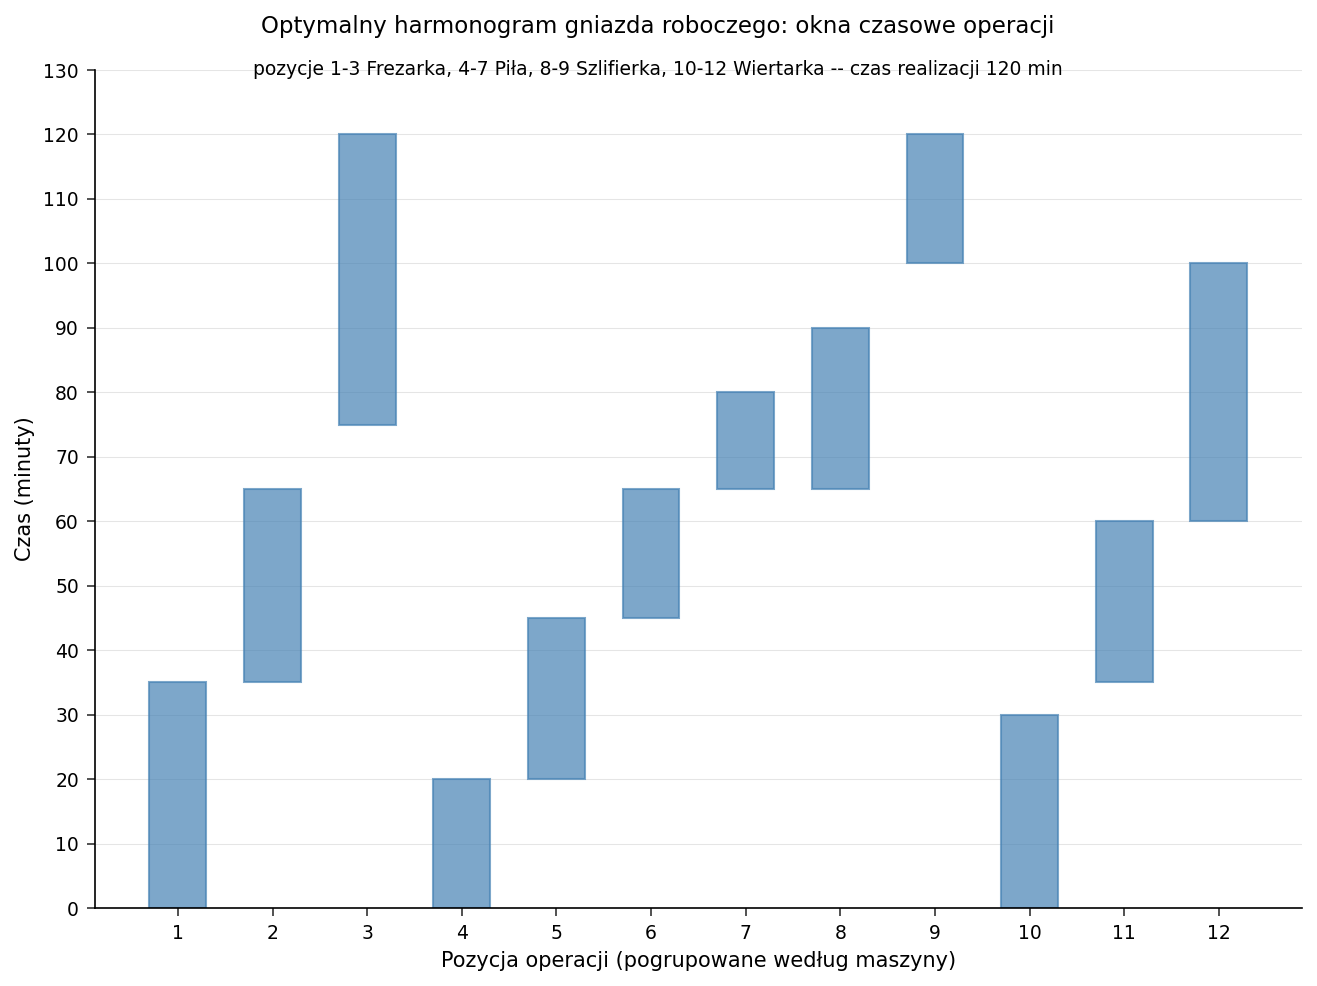

In [4]:
DANE ganttdata;
    USTAW schedule;
    slot + 1;
WYKONAJ;

PROCEDURA DRUKUJ DANE=ganttdata noobs ETYKIETA;
    TYTUŁ 'Harmonogram według pozycji (kolejność pozycji odpowiada wykresowi poniżej)';
    ZMIENNA slot mname jobname START FINISH;
    ETYKIETA slot="Pozycja" mname="Maszyna" jobname="Część"
             START="Start (min)" FINISH="Koniec (min)";
WYKONAJ;

PROCEDURA SGPLOT DANE=ganttdata noautolegend;
    TYTUŁ 'Optymalny harmonogram gniazda roboczego: okna czasowe operacji';
    title2 'pozycje 1-3 Frezarka, 4-7 Piła, 8-9 Szlifierka, 10-12 Wiertarka -- czas realizacji 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ETYKIETA='Pozycja operacji (pogrupowane według maszyny)' integer
          VALUES=(1 TO 12 WEDŁUG 1);
    YAXIS ETYKIETA='Czas (minuty)' grid VALUES=(0 TO 130 WEDŁUG 10);
WYKONAJ;
TYTUŁ;

## Interpretacja wyników

- **Optymalność.** Solver MILP zwrócił `Solution Status = Optimal` z `Objective Value = 120`, więc **120 minut to dowodliwie najkrótszy możliwy czas realizacji** dla tej instancji — żaden harmonogram nie może zakończyć się wcześniej. Ten certyfikat to właśnie to, co formuła programowania matematycznego daje ci ponad czyste przeszukiwanie dopuszczalności.

- **Harmonogram honoruje każde ograniczenie.** Czytając tabelę według maszyn, żadne dwie operacje na tej samej maszynie się nie nakładają (np. na Pile: Wał 0–20, Wspornik 20–45, Obudowa 45–65, Kołnierz 65–80), a każda część przebiega w kolejności technologicznej (np. Obudowa: Wiertarka 0–30, potem Piła 45–65, potem Frezarka 75–120). Wykres pływających pasków pokazuje to samo: w obrębie pasma pozycji każdej maszyny okna czasowe układają się jak kafelki bez kolizji.

- **Co wyznacza długość harmonogramu.** Dwie operacje kończą się dokładnie w minucie 120 — Szlifierka Wspornika (pozycja 9) i Frezarka Obudowy (pozycja 3). Obie dotykają czasu realizacji, więc maszyny Szlifierka i Frezarka leżą na ścieżce krytycznej; dalsze skrócenie czasu realizacji wymagałoby zmiany samej instancji (szybsze operacje, dodatkowa maszyna lub złagodzone następstwo), a nie jedynie zmiany kolejności.

- **Jak to się skaluje.** Formuła rośnie naturalnie: dodaj maszynę jako kolejną wartość `machine`, dodaj części jako więcej wierszy `jobshop` lub modeluj daty udostępnienia i terminy, ograniczając `s[o]` i dodając ograniczenia terminowe. Dopuszczenie, by maszyna wykonywała kilka zadań naraz (przepustowość >1), zastępuje parową rozłączność ograniczeniem zasobu kumulacyjnego. Ten sam MILP w OPTMODEL obsłuży wówczas bogatsze reguły hali produkcyjnej bez zmiany solvera.